In [2]:
# ============================================
# 1. Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
# ============================================
# 2. Load Data
# ============================================

male_file = "male_file.xlsx"
female_file = "female_file.xlsx"

male = pd.read_excel(male_file)
female = pd.read_excel(female_file)

data = pd.concat([male, female], ignore_index=True)

data.columns = data.columns.str.strip()

In [4]:
# ============================================
# 3. Encode Sex
# ============================================

data["Sex"] = data["Sex"].map({"M":0, "F":1})

In [5]:
# ============================================
# 4. Build Tree-Level Dataset
# ============================================

tree_mean = data.groupby("Tree_ID").mean(numeric_only=True)
tree_std = data.groupby("Tree_ID").std(numeric_only=True)

tree_dataset = tree_mean.join(tree_std, rsuffix="_std")

tree_sex = data.groupby("Tree_ID")["Sex"].first()

tree_dataset["Sex"] = tree_sex

print("Tree-level dataset shape:", tree_dataset.shape)

Tree-level dataset shape: (172, 24)


In [6]:
# ============================================
# 5. Prepare Clustering Data
# ============================================

X = tree_dataset.drop(columns=["Sex"])
y = tree_dataset["Sex"]

In [7]:
# ============================================
# 6. Standardize Features
# ============================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# ============================================
# 7. PCA Dimensionality Reduction
# ============================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance (PCA):")
print(pca.explained_variance_ratio_)


Explained variance (PCA):
[0.24445609 0.10906626]


In [9]:
# ============================================
# 8. K-Means Clustering
# ============================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

C:\Users\lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
# ============================================
# 9. Create Result DataFrame
# ============================================

cluster_df = pd.DataFrame()

cluster_df["PC1"] = X_pca[:,0]
cluster_df["PC2"] = X_pca[:,1]
cluster_df["Cluster"] = clusters
cluster_df["Sex"] = y.values

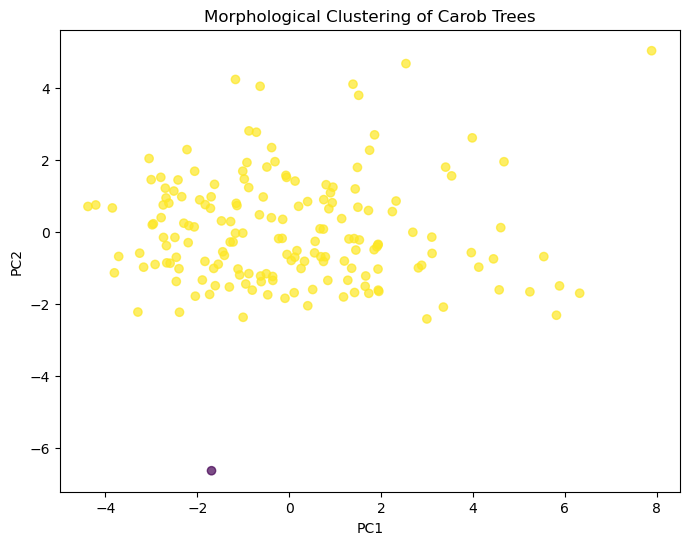

In [11]:
# ============================================
# 10. Plot Clusters in PCA Space
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    c=cluster_df["Cluster"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Morphological Clustering of Carob Trees")

plt.show()

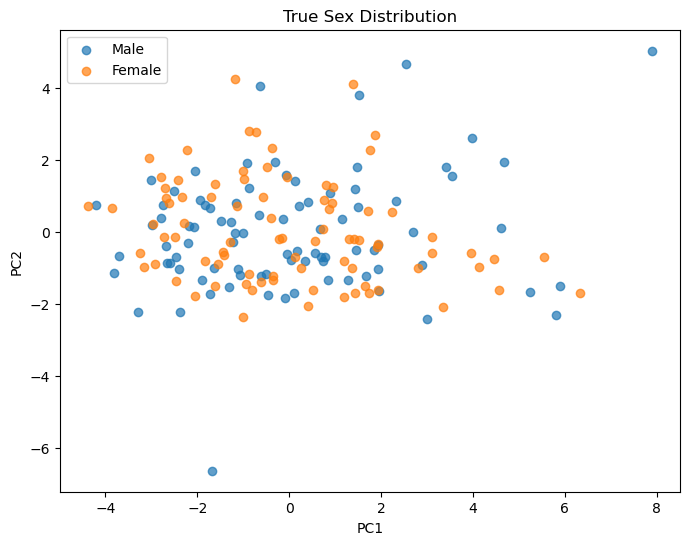

In [12]:
# ============================================
# 11. Plot True Sex Distribution
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    cluster_df[cluster_df["Sex"]==0]["PC1"],
    cluster_df[cluster_df["Sex"]==0]["PC2"],
    label="Male",
    alpha=0.7
)

plt.scatter(
    cluster_df[cluster_df["Sex"]==1]["PC1"],
    cluster_df[cluster_df["Sex"]==1]["PC2"],
    label="Female",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("True Sex Distribution")

plt.legend()

plt.show()

In [13]:
# ============================================
# 12. Cluster vs Sex Table
# ============================================

cluster_sex_table = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Sex"]
)

print("\nCluster vs Sex distribution:\n")
print(cluster_sex_table)


Cluster vs Sex distribution:

Sex       0   1
Cluster        
0         1   0
1        86  85


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


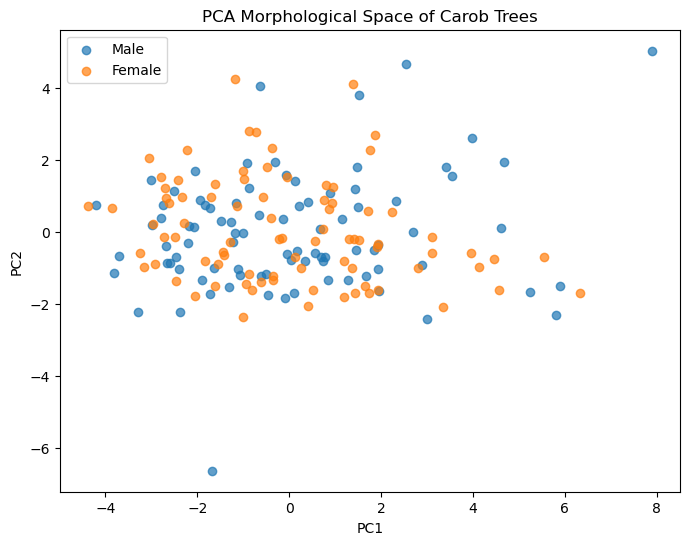

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    label="Male",
    alpha=0.7
)

plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    label="Female",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Morphological Space of Carob Trees")

plt.legend()

# Save as PDF
plt.savefig("PCA.pdf", format="pdf")

# Save as EPS (optional)
plt.savefig("PCA.eps", format="eps")

plt.show()